# Pearson correlation matrix — SUS, UEQ, Cognitive value, Intuitiveness, Visualization

Scoring conventions used:
- **SUS** (SUS_1–SUS_9, SUS_10): standard Brooke (1996) scoring. Odd items (SUS_1,3,5,7,9) are positively worded → `score - 1`. Even items (SUS_2,4,6,8,SUS_10) are negatively worded → `5 - score`. Sum of the 10 contributions (0–40) × 2.5 → 0–100 scale.
- **UEQ** (UEQ_1–UEQ_8, 1–7 raw scale): centered by subtracting 4 → −3..+3 scale. No reverse-coding applied (all items assumed same polarity in this dataset). Pragmatic = mean(UEQ_1–UEQ_4), Hedonic = mean(UEQ_5–UEQ_8).
- **Cognitive_value** = mean(P064, P301, P060, P027), raw scale, no reverse-coding.
- **Intuitiveness** = mean(P088, P026, P4026A), raw scale, no reverse-coding.
- **Visualization** = mean(P106,P089,P098,P097, P022A,P067), raw scale, no reverse-coding.

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from pathlib import Path

# Paths are relative to the repository root (the folder with instrument.Rproj),
# found by going up from the folder where the notebook is run.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "instrument.Rproj").exists())
PHASE_DIR = ROOT / "phase3-validation"
DATA_FILE = PHASE_DIR / "data" / "prepared" / "ratings_grades.csv"
OUTPUT_DIR = PHASE_DIR / "02_scale-correlations" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")
df.head()

,id,seed,stimulus,P026,P088,P4026A,P022A,P067,P089,P097,...,SUS_1,SUS_2,SUS_3,SUS_4,SUS_5,SUS_6,SUS_7,SUS_8,SUS_9,SUS_10
0,FOR-0014,1886876404,Power BI,6,5,5,7,5.0,6,7,...,4,2,3,1,4,3,3,3,4,4
1,FOR-0018,823070095,Tableau,7,7,6,6,7.0,5,5,...,3,2,4,1,4,2,4,3,4,2
2,FOR-0023,113523666,JMP,7,7,7,7,7.0,7,7,...,5,1,5,1,4,1,4,1,5,3
3,FOR-0024,675873429,Qlik,7,7,7,7,7.0,7,7,...,5,1,5,1,5,1,5,1,5,3
4,FOR-0025,886668237,Tableau,3,6,6,7,4.0,6,6,...,4,3,3,2,4,2,3,2,5,3


## Compute composite scores

In [2]:
# --- SUS: reverse-code negative items, sum, rescale to 0-100 ---
sus_pos = ['SUS_1', 'SUS_3', 'SUS_5', 'SUS_7', 'SUS_9']
sus_neg = ['SUS_2', 'SUS_4', 'SUS_6', 'SUS_8', 'SUS_10']

sus_contrib = pd.DataFrame(index=df.index)
for c in sus_pos:
    sus_contrib[c] = df[c] - 1
for c in sus_neg:
    sus_contrib[c] = 5 - df[c]

df['SUS'] = sus_contrib.sum(axis=1, min_count=10) * 2.5

In [3]:
# --- UEQ: center 1-7 scale on 0 (range -3..+3), split pragmatic / hedonic ---
ueq_pragmatic_items = ['UEQ_1', 'UEQ_2', 'UEQ_3', 'UEQ_4']
ueq_hedonic_items = ['UEQ_5', 'UEQ_6', 'UEQ_7', 'UEQ_8']

df['UEQ_pragmatic'] = (df[ueq_pragmatic_items] - 4).mean(axis=1)
df['UEQ_hedonic'] = (df[ueq_hedonic_items] - 4).mean(axis=1)

In [4]:
# --- Cognitive value & Intuitiveness: simple mean of raw items ---
cognitive_items = ['P064', 'P301', 'P060', 'P027']
intuitiveness_items = ['P088', 'P026', 'P4026A']
visualization_items = ['P106','P089','P098','P097', 'P022A','P067']  # e.g. ['P0xx', 'P0yy', ...]

df['Cognitive_value'] = df[cognitive_items].mean(axis=1)
df['Intuitiveness'] = df[intuitiveness_items].mean(axis=1)
df['Visualization'] = df[visualization_items].mean(axis=1)


In [5]:
composite_cols = ['SUS', 'UEQ_hedonic', 'UEQ_pragmatic', 'Cognitive_value', 'Intuitiveness', 'Visualization']
#composite_cols = ['Cognitive_value', 'Intuitiveness', 'Visualization']
composite_df = df[composite_cols]
composite_df.describe()

,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
count,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000
mean,70.331858,1.132743,1.706858,6.049410,5.520649,6.007965
std,14.751664,1.169791,0.937827,0.705327,1.068894,0.582608
min,30.000000,-3.000000,-1.250000,2.250000,1.666667,4.166667
25%,60.000000,0.500000,1.250000,5.750000,5.000000,5.666667
50%,72.500000,1.250000,1.750000,6.000000,5.666667,6.000000
75%,80.000000,2.000000,2.437500,6.500000,6.333333,6.500000
max,100.000000,3.000000,3.000000,7.000000,7.000000,7.000000


## Pearson correlation matrix

Pairwise-complete correlations (rows with `NaN` for a given pair are dropped only for that pair, following pandas' default `.corr()` behavior).

In [6]:
corr = composite_df.corr(method='pearson')
corr.round(3)

,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
SUS,1.000,0.280,0.660,0.398,0.593,0.466
UEQ_hedonic,0.280,1.000,0.476,0.564,0.350,0.299
UEQ_pragmatic,0.660,0.476,1.000,0.500,0.696,0.503
Cognitive_value,0.398,0.564,0.500,1.000,0.449,0.573
Intuitiveness,0.593,0.350,0.696,0.449,1.000,0.488
Visualization,0.466,0.299,0.503,0.573,0.488,1.000


In [7]:
def corr_with_pvalues(data):
    cols = data.columns
    r_mat = pd.DataFrame(np.nan, index=cols, columns=cols)
    p_mat = pd.DataFrame(np.nan, index=cols, columns=cols)
    n_mat = pd.DataFrame(np.nan, index=cols, columns=cols)
    for c1, c2 in itertools.combinations_with_replacement(cols, 2):
        sub = data[[c1, c2]].dropna() # pairwise deletion
        x, y = sub.iloc[:, 0], sub.iloc[:, 1]  # positional, safe when c1 == c2
        n = len(sub)
        n_mat.loc[c1, c2] = n_mat.loc[c2, c1] = n
        if n > 1 and x.std() > 0 and y.std() > 0:
            r, p = pearsonr(x, y)
        else:
            r, p = np.nan, np.nan
        r_mat.loc[c1, c2] = r_mat.loc[c2, c1] = r
        p_mat.loc[c1, c2] = p_mat.loc[c2, c1] = p
    return r_mat, p_mat, n_mat

r_mat, p_mat, n_mat = corr_with_pvalues(composite_df)
print("r:")
display(r_mat.round(3))
print("p:")
display(p_mat.round(10))
print("n:")
display(n_mat)

r:


,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
SUS,1.000,0.280,0.660,0.398,0.593,0.466
UEQ_hedonic,0.280,1.000,0.476,0.564,0.350,0.299
UEQ_pragmatic,0.660,0.476,1.000,0.500,0.696,0.503
Cognitive_value,0.398,0.564,0.500,1.000,0.449,0.573
Intuitiveness,0.593,0.350,0.696,0.449,1.000,0.488
Visualization,0.466,0.299,0.503,0.573,0.488,1.000


p:


,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
SUS,0.000000e+00,1.970300e-05,0.0,5.000000e-10,0.000000e+00,0.000000
UEQ_hedonic,1.970300e-05,0.000000e+00,0.0,0.000000e+00,6.340000e-08,0.000005
UEQ_pragmatic,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000
Cognitive_value,5.000000e-10,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000
Intuitiveness,0.000000e+00,6.340000e-08,0.0,0.000000e+00,0.000000e+00,0.000000
Visualization,0.000000e+00,4.752700e-06,0.0,0.000000e+00,0.000000e+00,0.000000


n:


,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
SUS,226.0,226.0,226.0,226.0,226.0,226.0
UEQ_hedonic,226.0,226.0,226.0,226.0,226.0,226.0
UEQ_pragmatic,226.0,226.0,226.0,226.0,226.0,226.0
Cognitive_value,226.0,226.0,226.0,226.0,226.0,226.0
Intuitiveness,226.0,226.0,226.0,226.0,226.0,226.0
Visualization,226.0,226.0,226.0,226.0,226.0,226.0


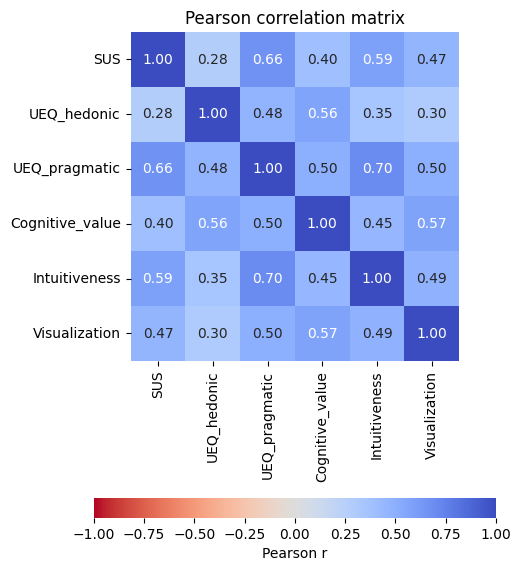

In [13]:
plt.figure(figsize=(7, 6))
# Gerando o heatmap com a barra de cores na horizontal e embaixo
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm_r",
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={
        "label": "Pearson r",
        "orientation": "horizontal",  # horizontal bar
        "pad": 0.25,  # off set
        "shrink": 0.6,  # bar lenght
    },
)
#sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm_r", vmin=-1, vmax=1, square=True, cbar_kws={'label': "Pearson r"}) #lateral legend
plt.title("Pearson correlation matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_matrix.png", dpi=150)
plt.show()

In [9]:
corr.to_csv(OUTPUT_DIR / "pearson_correlation_matrix.csv")
r_mat.to_csv(OUTPUT_DIR / "pearson_correlation_matrix_r.csv")
p_mat.to_csv(OUTPUT_DIR / "pearson_correlation_matrix_p.csv")
print("Saved: pearson_correlation_matrix.csv, pearson_correlation_matrix_r.csv, pearson_correlation_matrix_p.csv, correlation_matrix.png")

Saved: pearson_correlation_matrix.csv, pearson_correlation_matrix_r.csv, pearson_correlation_matrix_p.csv, correlation_matrix.png
